# Descriptive Statistics Analysis

This notebook provides a complete descriptive statistics analysis of the uploaded CSV dataset, divided into three main sections: Measures of Central Tendency, Measures of Variability, and Measures of Frequency Distribution. The output is designed to be clean, professional, and easy to understand for reports or assignments.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Matplotlib for better readability
plt.rcParams.update({'font.size': 12, 'figure.autolayout': True})


### Dataset Loading and Initial Exploration

First, we will load the CSV file into a pandas DataFrame. Following this, we'll perform an initial exploration to understand the dataset's structure, including its dimensions, column types, and the presence of any missing values.

---

In [8]:
# Define the file path
file_path = '/content/drive/MyDrive/Colab Notebooks/TPSM/dimension_01_stage_01_preprocessing_part02.csv'

# Attempt to load the CSV file
try:
    df = pd.read_csv(file_path)
    print(f"Dataset '{file_path}' loaded successfully.\n")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct.")
    df = None

if df is not None:
    print("#### Preview of the Dataset (First 5 Rows):\n")
    display(df.head())

    print("\n#### Dataset Shape:\n")
    print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

    print("#### Column Names and Data Types:\n")
    df.info()

    print("\n#### Missing Values Count Per Column:\n")
    display(df.isnull().sum())

    # Separate numeric and categorical columns
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

    print("\n#### Separated Columns:\n")
    print("Numeric Columns:", numeric_cols)
    print("Categorical Columns:", categorical_cols)

    if not numeric_cols and not categorical_cols:
        print("No numeric or categorical columns found for analysis.")


Dataset '/content/drive/MyDrive/Colab Notebooks/TPSM/dimension_01_stage_01_preprocessing_part02.csv' loaded successfully.

#### Preview of the Dataset (First 5 Rows):



,channel_name,category,sub_category,customer_remarks,tenure_bucket,agent_shift,csat_score,response_minutes,retention_label
0,Outcall,Product Queries,Life Insurance,NaN,On Job Training,Morning,5,34.0,1.0
1,Outcall,Product Queries,Product Specific Information,NaN,>90,Morning,5,2.0,1.0
2,Inbound,Order Related,Installation/demo,NaN,On Job Training,Evening,5,22.0,1.0
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,>90,Evening,5,20.0,1.0
4,Inbound,Cancellation,Not Needed,NaN,0-30,Morning,5,2.0,1.0



#### Dataset Shape:

The dataset contains 2894 rows and 9 columns.

#### Column Names and Data Types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2894 entries, 0 to 2893
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   channel_name      2894 non-null   object 
 1   category          2894 non-null   object 
 2   sub_category      2894 non-null   object 
 3   customer_remarks  979 non-null    object 
 4   tenure_bucket     2894 non-null   object 
 5   agent_shift       2894 non-null   object 
 6   csat_score        2894 non-null   int64  
 7   response_minutes  2846 non-null   float64
 8   retention_label   2737 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 203.6+ KB

#### Missing Values Count Per Column:



,0
channel_name,0
category,0
sub_category,0
customer_remarks,1915
tenure_bucket,0
agent_shift,0
csat_score,0
response_minutes,48
retention_label,157



#### Separated Columns:

Numeric Columns: ['csat_score', 'response_minutes', 'retention_label']
Categorical Columns: ['channel_name', 'category', 'sub_category', 'customer_remarks', 'tenure_bucket', 'agent_shift']


### 1. Measures of Central Tendency

This section calculates and presents the Mean, Median, and Mode for all numeric columns in the dataset. These measures help us understand the typical or central value of each variable.

---

In [9]:
if df is not None and numeric_cols:
    print("#### Table: Measures of Central Tendency for Numeric Columns\n")

    # Compute mean, median, and mode
    mean_values = df[numeric_cols].mean()
    median_values = df[numeric_cols].median()

    # Mode can have multiple values, so handle it carefully. Transpose to align with other stats.
    mode_values_df = df[numeric_cols].mode().transpose()
    mode_values_df.columns = [f'Mode_{i+1}' for i in range(mode_values_df.shape[1])]

    # Combine into a single DataFrame
    central_tendency_df = pd.DataFrame({
        'Mean': mean_values,
        'Median': median_values
    })
    central_tendency_df = central_tendency_df.merge(mode_values_df, left_index=True, right_index=True, how='left')

    # Display the table
    display(central_tendency_df)

    # Save to CSV
    central_tendency_df.to_csv('central_tendency_summary.csv', index=True)
    print("\nSummary of Central Tendency saved to 'central_tendency_summary.csv'.")
else:
    print("No numeric columns available to compute measures of central tendency.")


#### Table: Measures of Central Tendency for Numeric Columns



,Mean,Median,Mode_1
csat_score,4.224257,5.0,5.0
response_minutes,1463.742446,5.0,1.0
retention_label,0.839971,1.0,1.0



Summary of Central Tendency saved to 'central_tendency_summary.csv'.


### 2. Measures of Variability

This section computes and displays the Range, Variance, Standard Deviation, and Interquartile Range (IQR) for all numeric columns. These measures describe the spread or dispersion of the data points around the central value.

---

In [10]:
if df is not None and numeric_cols:
    print("#### Table: Measures of Variability for Numeric Columns\n")

    # Compute variability measures
    range_values = df[numeric_cols].max() - df[numeric_cols].min()
    variance_values = df[numeric_cols].var()
    std_dev_values = df[numeric_cols].std()
    q1_values = df[numeric_cols].quantile(0.25)
    q3_values = df[numeric_cols].quantile(0.75)
    iqr_values = q3_values - q1_values

    # Combine into a single DataFrame
    variability_df = pd.DataFrame({
        'Range': range_values,
        'Variance': variance_values,
        'Standard Deviation': std_dev_values,
        'IQR': iqr_values
    })

    # Display the table
    display(variability_df)

    # Save to CSV
    variability_df.to_csv('variability_summary.csv', index=True)
    print("\nSummary of Variability saved to 'variability_summary.csv'.")
else:
    print("No numeric columns available to compute measures of variability.")


#### Table: Measures of Variability for Numeric Columns



,Range,Variance,Standard Deviation,IQR
csat_score,4.0,1.945889e+00,1.394951,1.0
response_minutes,45185.0,6.103168e+07,7812.277682,21.0
retention_label,1.0,1.344690e-01,0.366700,0.0



Summary of Variability saved to 'variability_summary.csv'.


### 3. Measures of Frequency Distribution

This section visualizes the frequency distribution of the dataset's columns using histograms for numeric data, boxplots for numeric data, and pie charts for categorical data. Each plot is generated individually for clarity.

---

#### Histograms for Numeric Columns

Histograms illustrate the distribution of numerical data by dividing the data into bins and showing the frequency of observations falling into each bin. They are useful for identifying the shape of the distribution, such as whether it's symmetric, skewed, or multimodal.


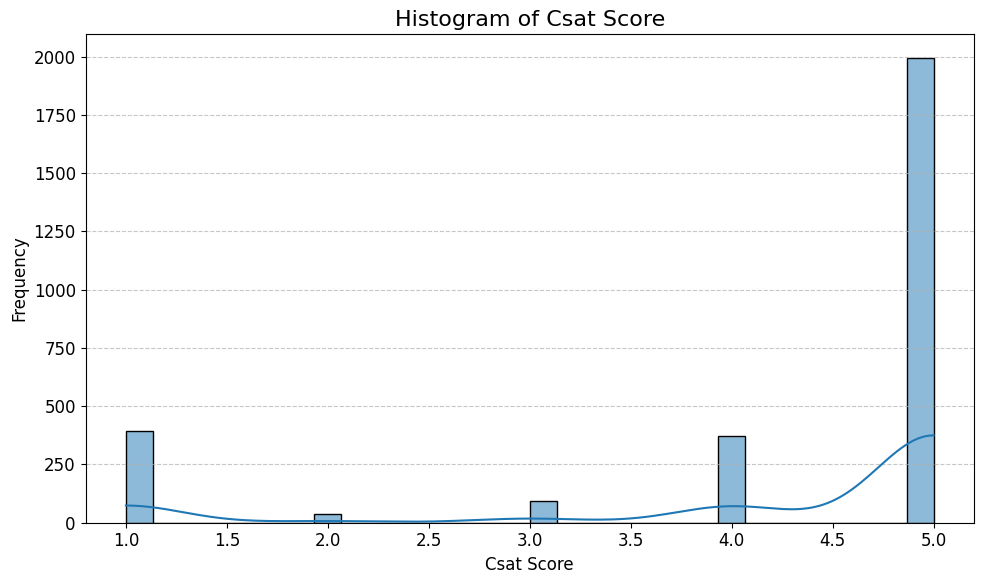

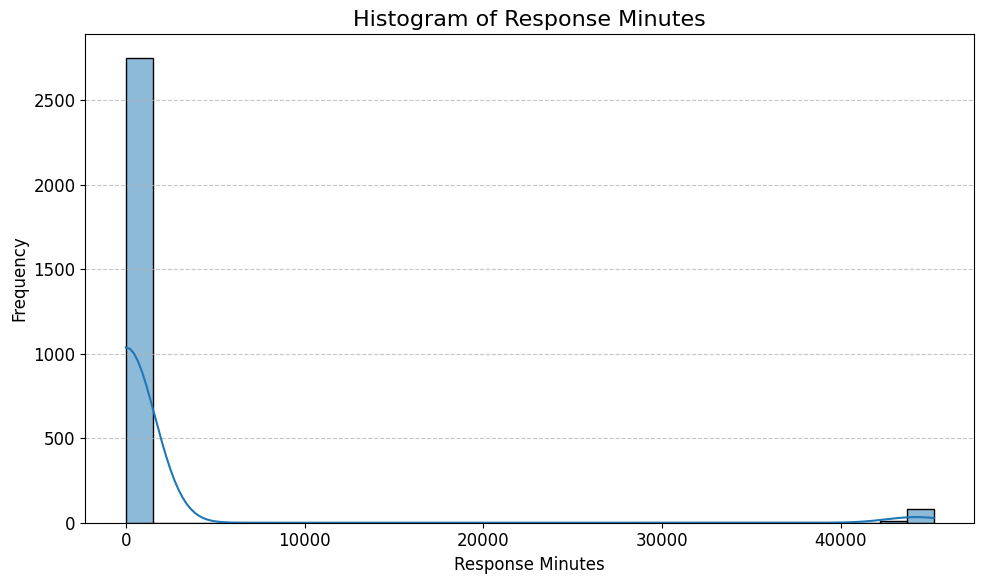

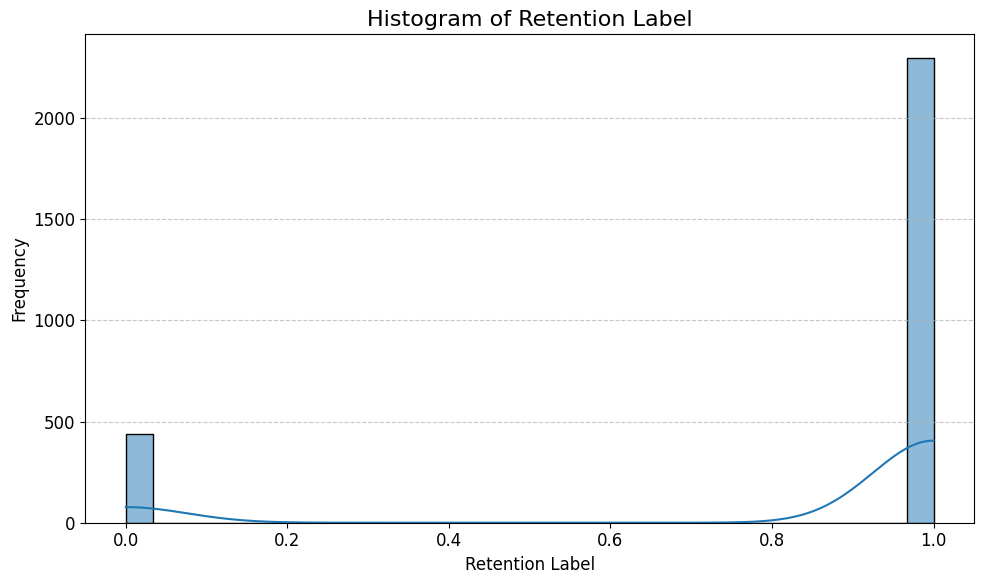

In [11]:
if df is not None and numeric_cols:
    for col in numeric_cols:
        plt.figure(figsize=(10, 6)) # Large figure size
        sns.histplot(df[col].dropna(), kde=True, bins=30) # Dropna for cleaner plot, add KDE
        plt.title(f'Histogram of {col.replace('_', ' ').title()}', fontsize=16)
        plt.xlabel(col.replace('_', ' ').title(), fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        print('\n' * 2) # Add spacing
else:
    print("No numeric columns to plot histograms.")


#### Boxplots for Numeric Columns

Boxplots display the distribution of numerical data and can quickly identify potential outliers. They show the median, quartiles (25th and 75th percentiles), and the range of the data.


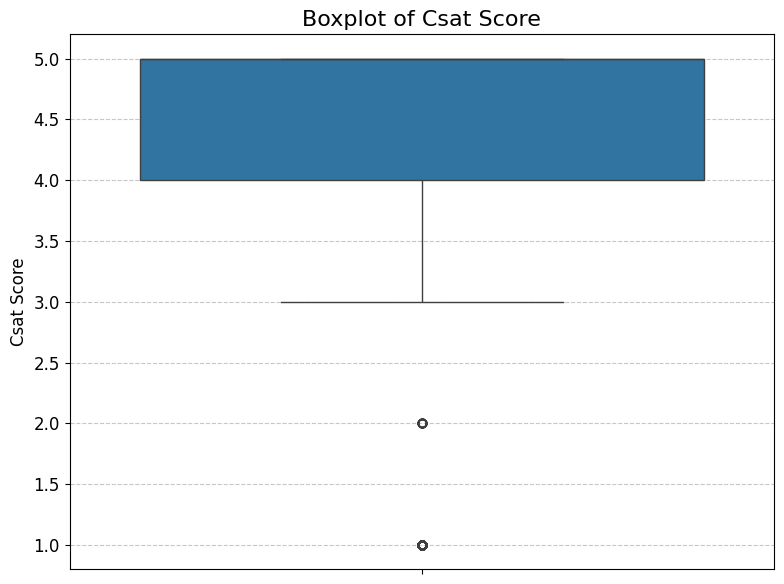

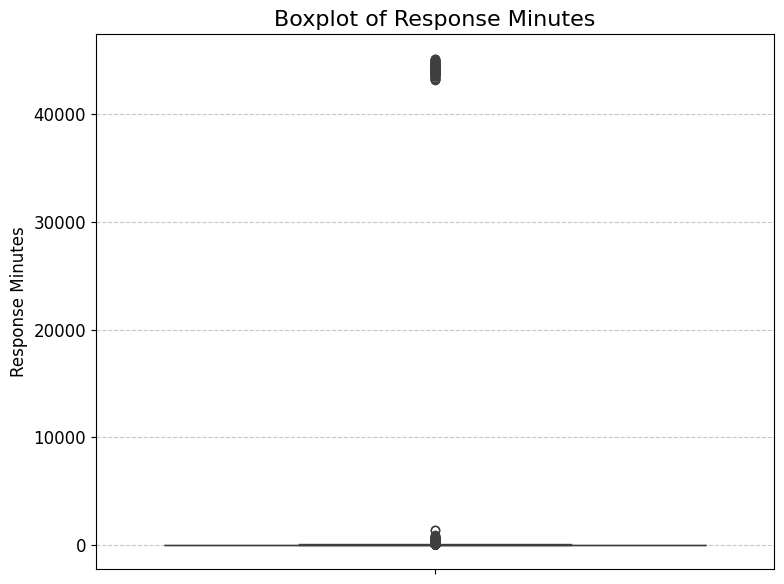

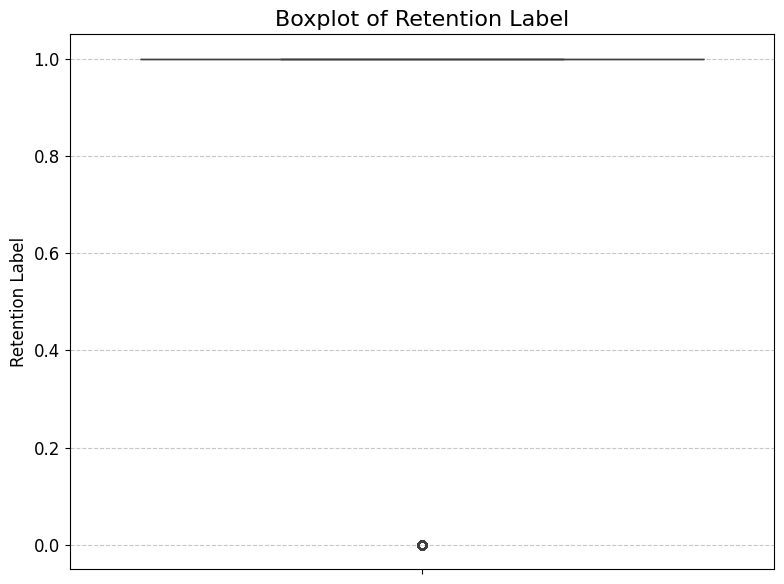

In [12]:
if df is not None and numeric_cols:
    for col in numeric_cols:
        plt.figure(figsize=(8, 6)) # Large figure size
        sns.boxplot(y=df[col].dropna())
        plt.title(f'Boxplot of {col.replace('_', ' ').title()}', fontsize=16)
        plt.ylabel(col.replace('_', ' ').title(), fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        print('\n' * 2) # Add spacing
else:
    print("No numeric columns to plot boxplots.")


#### Pie Charts for Categorical Columns

Pie charts represent the proportion of each category within a categorical variable. For readability, only the top categories (up to 9) will be displayed, with remaining categories and missing values grouped into an 'Other' slice.


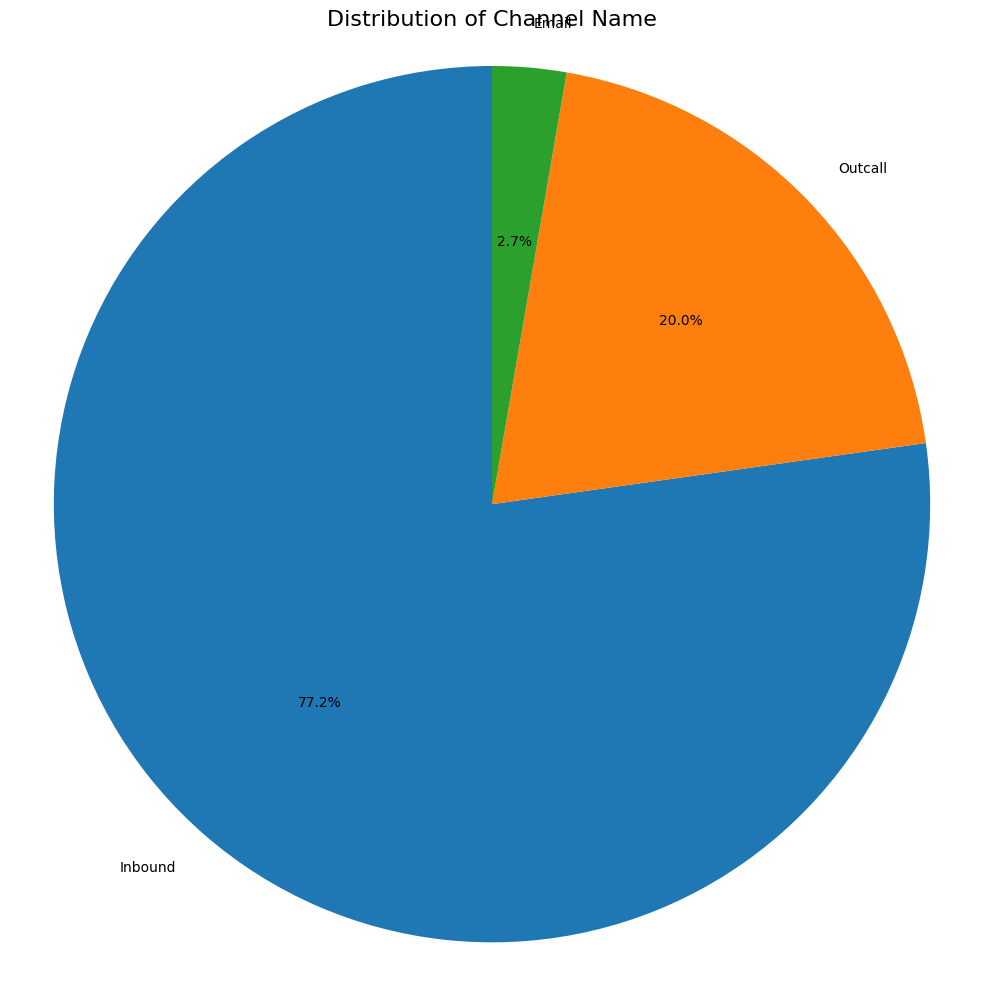

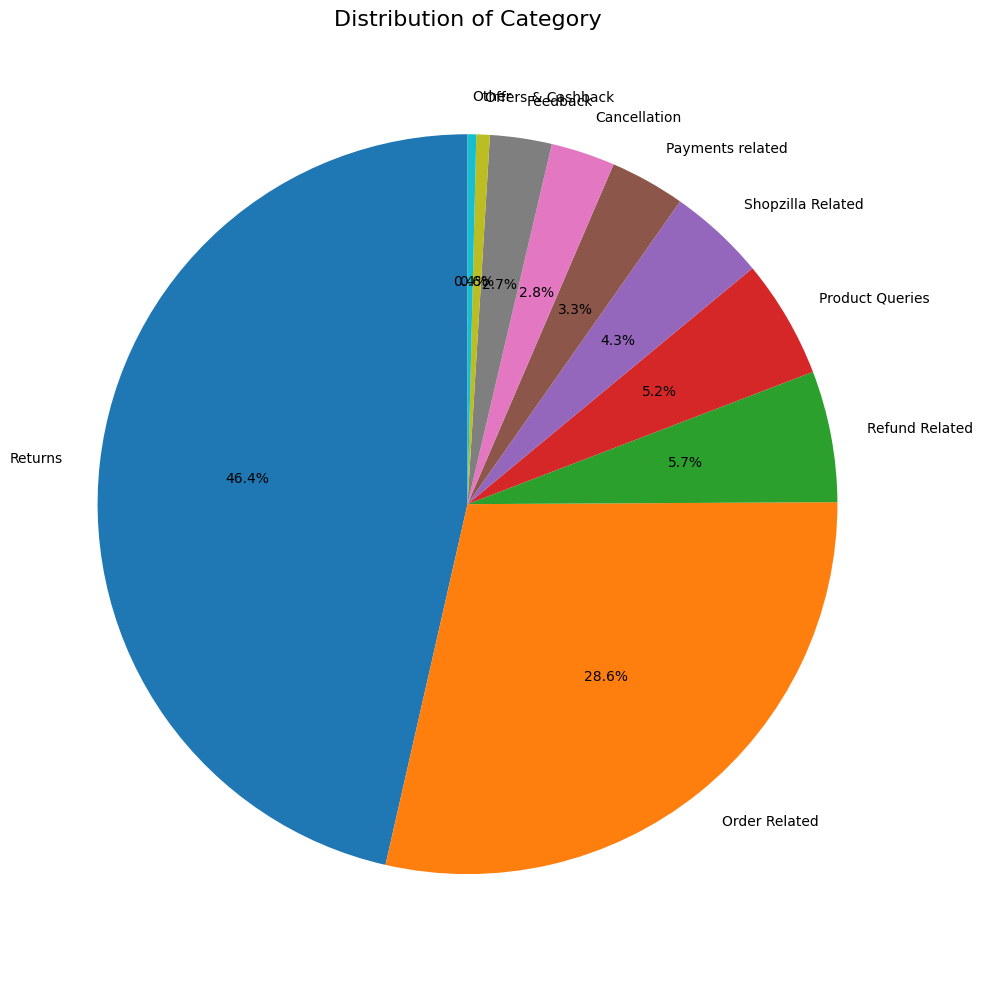

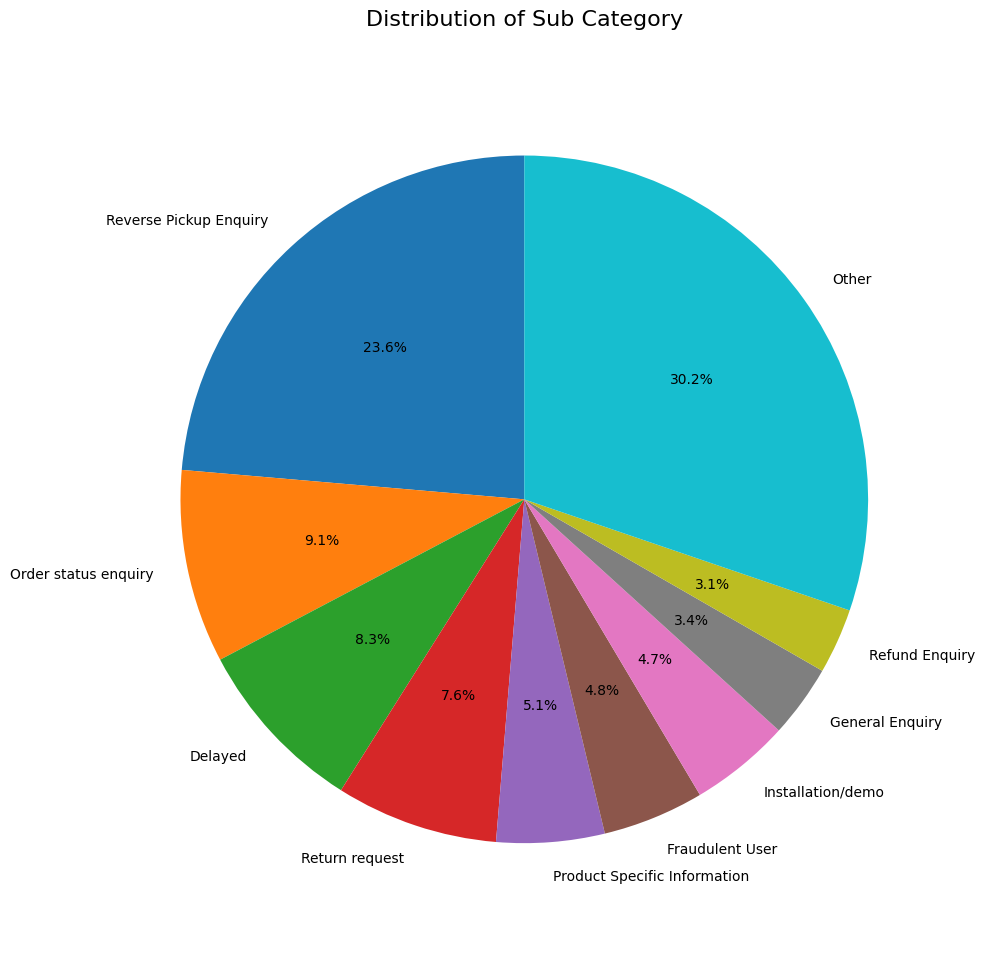

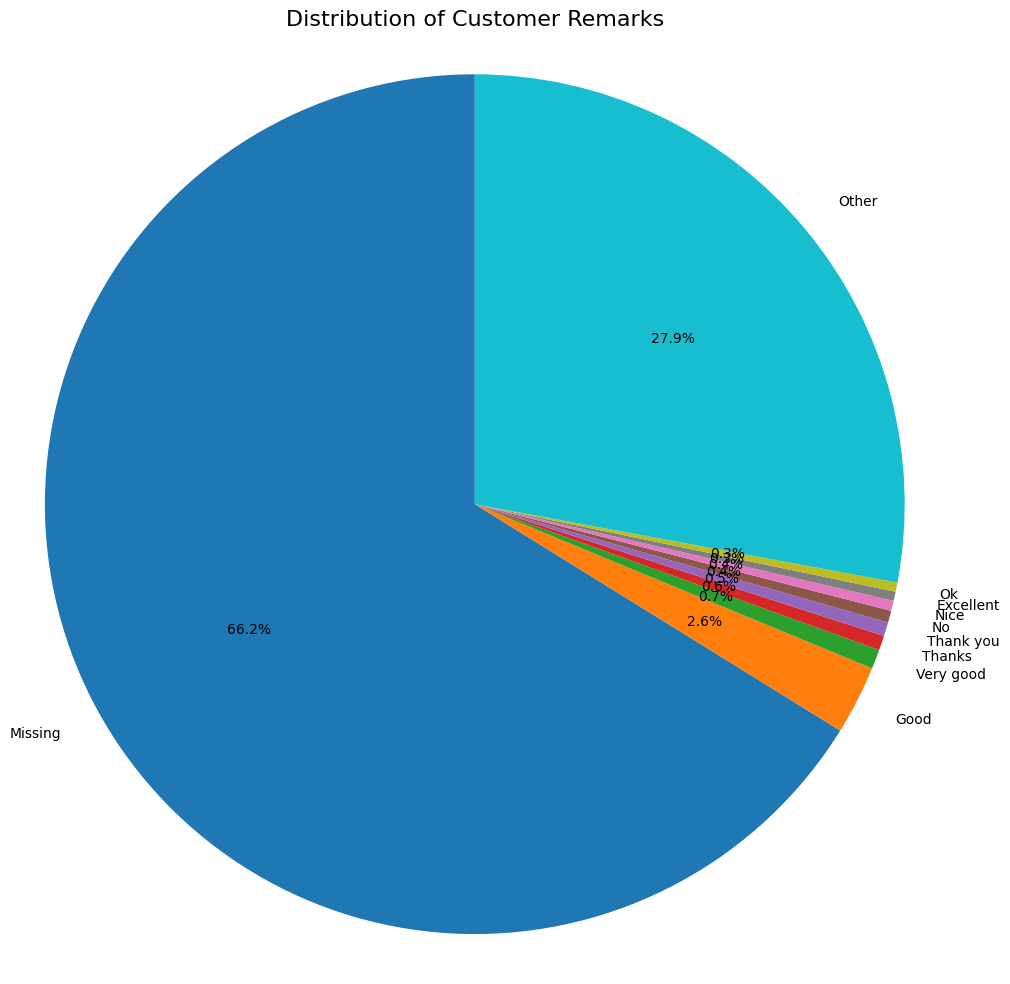

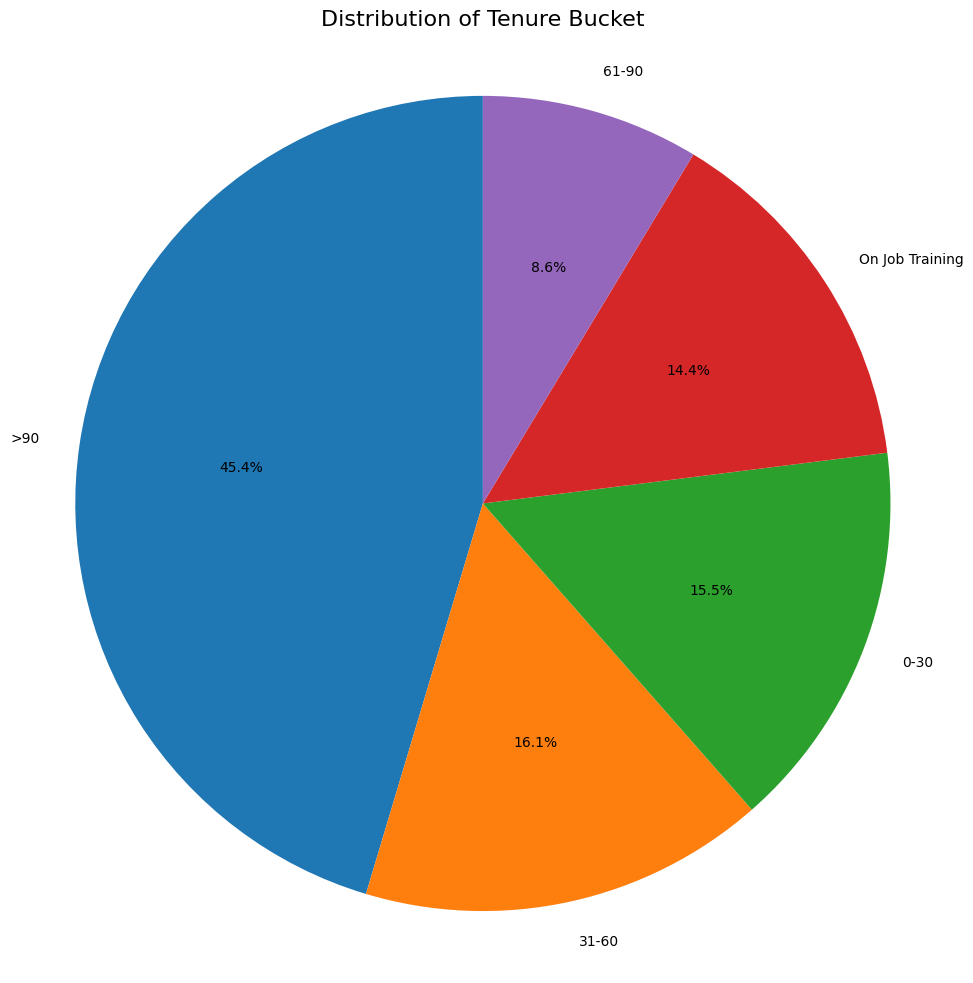

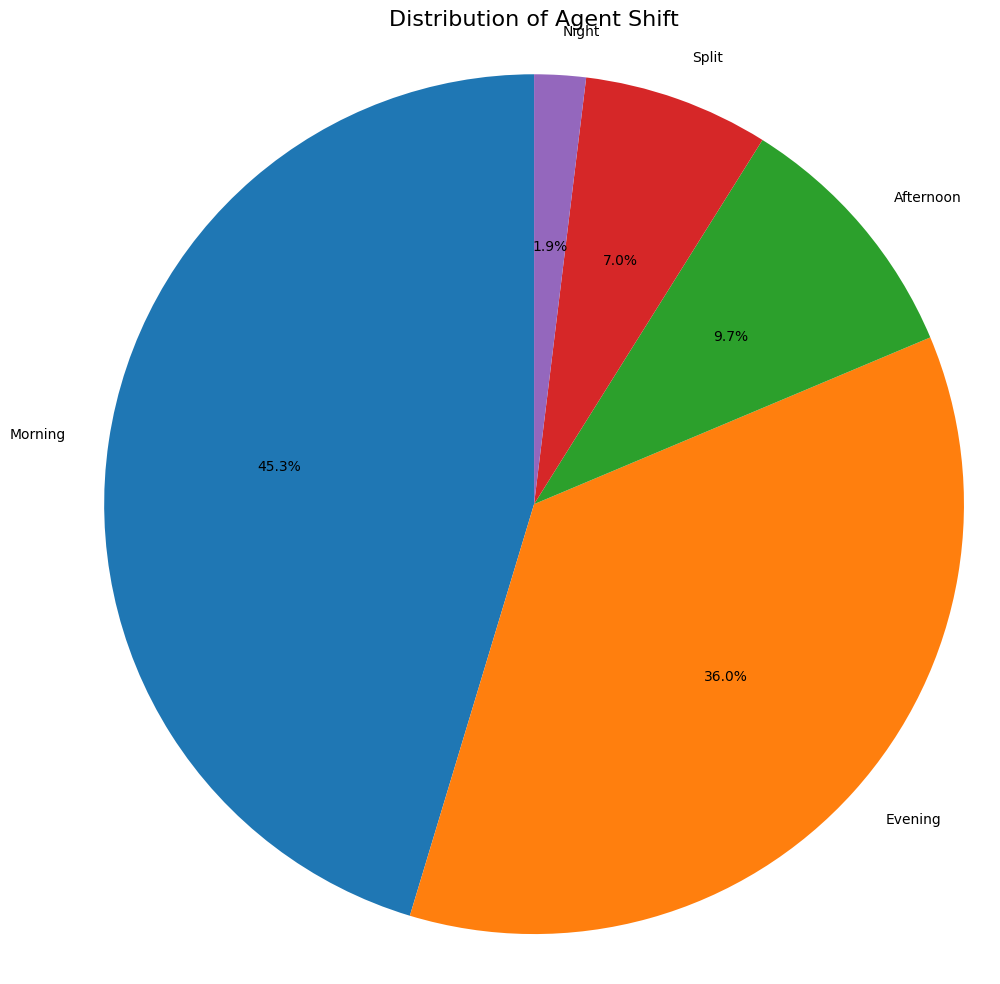

In [13]:
if df is not None and categorical_cols:
    for col in categorical_cols:
        plt.figure(figsize=(10, 10)) # Large figure size

        # Handle missing values and group less frequent categories
        value_counts = df[col].value_counts(dropna=False) # Include NaN in counts initially

        # If there are more than 9 distinct categories (including NaN if present)
        if len(value_counts) > 9:
            top_categories = value_counts.head(9) # Take top 9 categories
            other_count = value_counts.iloc[9:].sum() # Sum the rest
            if other_count > 0:
                final_counts = pd.concat([top_categories, pd.Series({'Other': other_count})])
            else:
                final_counts = top_categories
        else:
            final_counts = value_counts

        # Replace NaN index with 'Missing' for display
        final_counts.index = final_counts.index.fillna('Missing')

        plt.pie(final_counts, labels=final_counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
        plt.title(f'Distribution of {col.replace('_', ' ').title()}', fontsize=16)
        plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
        plt.show()
        print('\n' * 2) # Add spacing
else:
    print("No categorical columns to plot pie charts.")
